# Bank Marketing Campaign - Exploratory Data Analysis and Logistic Regression Model Training

## Problem Statement

A Portuguese bank is experiencing a decline in revenue. They want to identify existing customers who are more likely to take out a long-term deposit, allowing them to focus their marketing efforts and avoid wasting money on customers unlikely to sign up.

Marketing campaigns for this product are based on phone calls. If a user is not available at a given time, they will be called back at another time.

**This is a binary classification problem.** The target column `y` represents whether a customer subscribed to a long-term deposit as a result of the marketing campaign (yes/no). We will use a Logistic Regression model.

## EDA Pipeline

1. High level view of the data — shape, info, identify categorical vs numerical variables
2. Data cleaning — nulls, duplicates, noise columns
3. Descriptive statistics
4. Univariate analysis — graphing individual variables
5. Verbal analysis of univariate graphs
6. Multivariate analysis — correlational heatmap, boxplots
7. Verbal analysis of multivariate graphs
8. Feature engineering — outlier handling, encoding, scaling
9. Feature selection — SelectKBest with chi-square test
10. Train/test split and save

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

total_data = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=413&path=bank-marketing-campaign-data.csv", sep=";")
total_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Step 1: High Level View

In [2]:
# Dimensions of the dataset
print(total_data.shape)

# Data types and non-null counts
total_data.info()

(41188, 21)
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null

**Numerical columns:** `age`, `duration`, `campaign`, `pdays`, `previous`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`

**Categorical columns:** `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, `poutcome`, `y`

## Step 2: Data Cleaning

In [ ]:
# Check for duplicates before dropping
print(f"Duplicate rows: {total_data.duplicated().sum()}")


# Drop duplicates and reset index
rows_before = len(total_data)
total_data = total_data.drop_duplicates().reset_index(drop=True)
rows_after = len(total_data)
print(f"Rows before: {rows_before}")
print(f"Rows after: {rows_after}")
print(f"Duplicates removed: {rows_before - rows_after}")

# Check for null values
print(f"\nNull values per column:")
print(total_data.isnull().sum())

Duplicate rows: 12
Rows before: 41188
Rows after: 41176
Duplicates removed: 12

Null values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


## Step 3: Descriptive Statistics

In [3]:
# Numerical columns
total_data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [4]:
# All columns  
total_data.describe(include="all")

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41176.00000,41176,41176,41176,41176,41176,41176,41176,41176,41176,...,41176.000000,41176.000000,41176.000000,41176,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176
unique,NaN,12,4,8,3,3,3,2,10,5,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,2
top,NaN,admin.,married,university.degree,no,yes,no,cellular,may,thu,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,10419,24921,12164,32577,21571,33938,26135,13767,8618,...,NaN,NaN,NaN,35551,NaN,NaN,NaN,NaN,NaN,36537
mean,40.02380,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.567879,962.464810,0.173013,NaN,0.081922,93.575720,-40.502863,3.621293,5167.034870,NaN
std,10.42068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.770318,186.937102,0.494964,NaN,1.570883,0.578839,4.627860,1.734437,72.251364,NaN
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,NaN
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN


## Step 4: Univariate Analysis

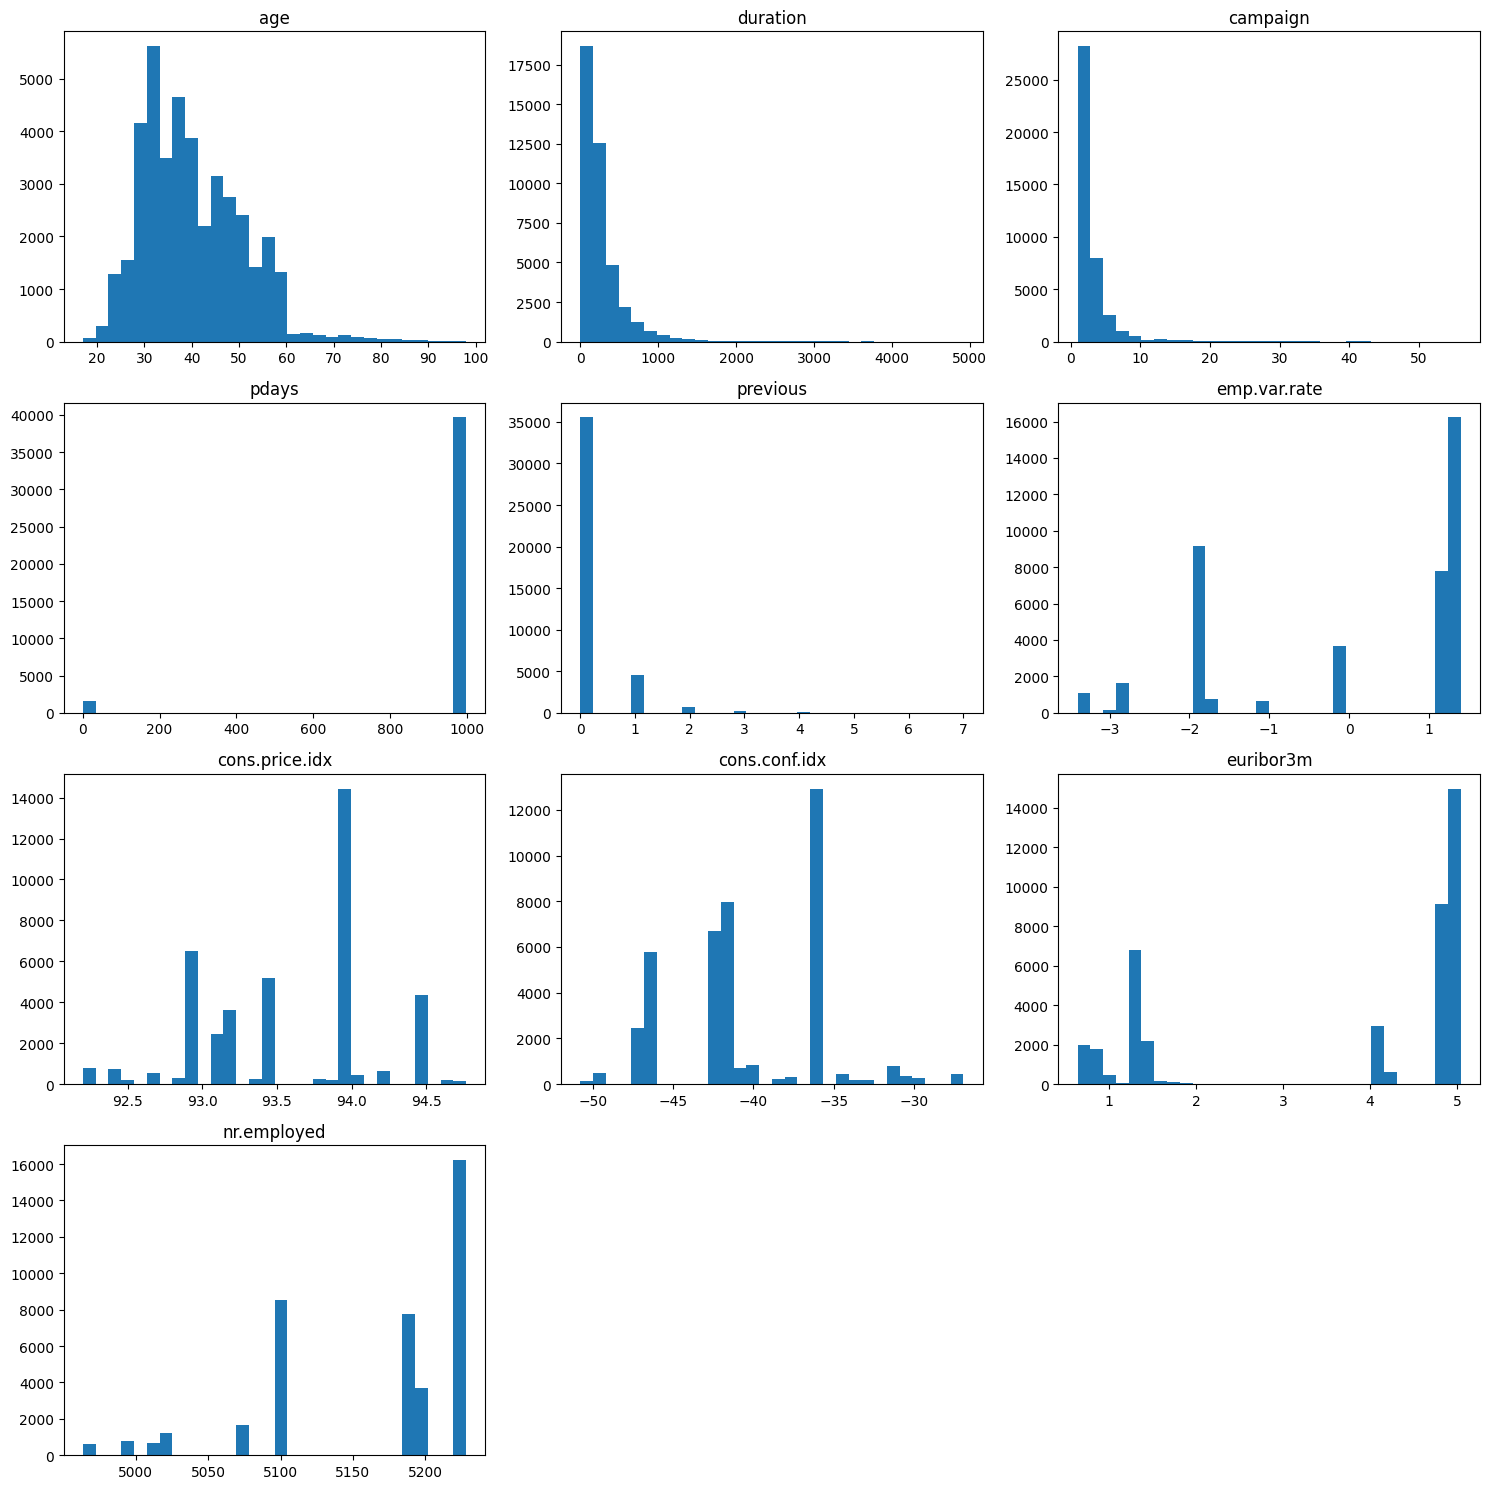

In [8]:
# Numerical columns - histograms
num_cols = ["age", "duration", "campaign", "pdays", "previous",
            "emp.var.rate", "cons.price.idx", "cons.conf.idx",
            "euribor3m", "nr.employed"]

fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(total_data[col], bins=30)
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

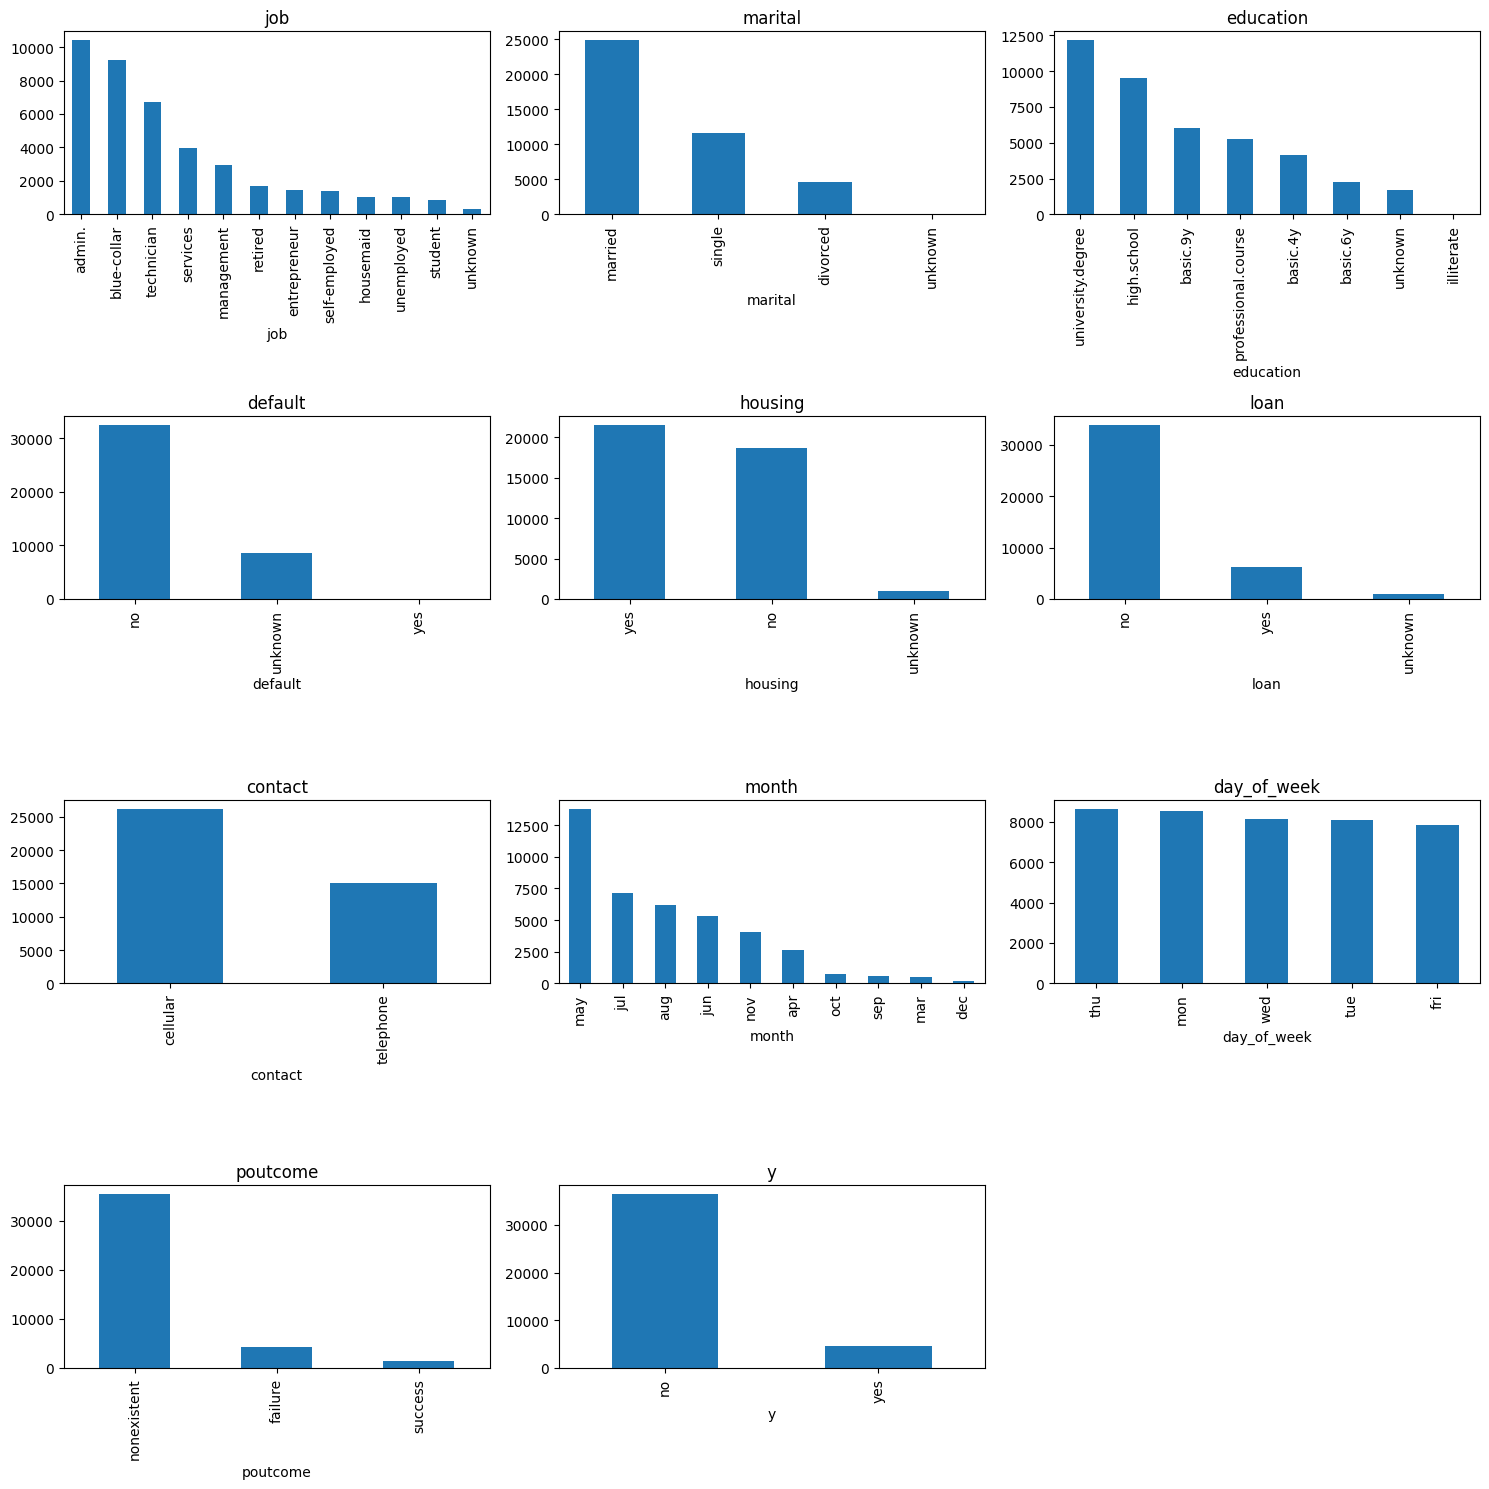

In [9]:
# Categorical columns - bar charts
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()

cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "day_of_week", "poutcome", "y"]

for i, col in enumerate(cat_cols):
    total_data[col].value_counts().plot(kind="bar", ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Step 5: Univariate Analysis 

- **Dataset:** About fourty thousand rows, 21 columns. No null values found. Very few duplicates.
- **Class imbalance:** The target column y is heavily skewed — approximately 4,600 "yes" vs 36,000 "no" (~90/10 split).
- **age:** Most customers are fairly young — majority below 60. 
- **duration:** Heavily right-skewed. Most calls are short. 
- **campaign:** Most customers were contacted only a few times, heavily skewed toward low values.
- **pdays:** Almost entirely 999. This is a sentinel value meaning "never previously contacted." Not a real number of days — needs to be engineered into a binary column.
- **default:** Near-zero variance — almost entirely "no." Strong candidate for removal. This is mostly a "noise" column. 
- **poutcome:** Dominated by "nonexistent" (never previously contacted). Minority values (success/failure) may still be predictive — keep for now.
- **Macroeconomic indicators** (emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed): These apply uniformly across all customers and show unusual distribution shapes as a result.

## Step 6: Multivariate Analysis

First we factorize categorical columns so the correlation heatmap math works. 

In [10]:
# Factorize categorical columns for correlation heatmap
total_data["job"] = pd.factorize(total_data["job"])[0]
total_data["marital"] = pd.factorize(total_data["marital"])[0]
total_data["education"] = pd.factorize(total_data["education"])[0]
total_data["default"] = pd.factorize(total_data["default"])[0]
total_data["housing"] = pd.factorize(total_data["housing"])[0]
total_data["loan"] = pd.factorize(total_data["loan"])[0]
total_data["contact"] = pd.factorize(total_data["contact"])[0]
total_data["month"] = pd.factorize(total_data["month"])[0]
total_data["day_of_week"] = pd.factorize(total_data["day_of_week"])[0]
total_data["poutcome"] = pd.factorize(total_data["poutcome"])[0]
total_data["y"] = pd.factorize(total_data["y"])[0]

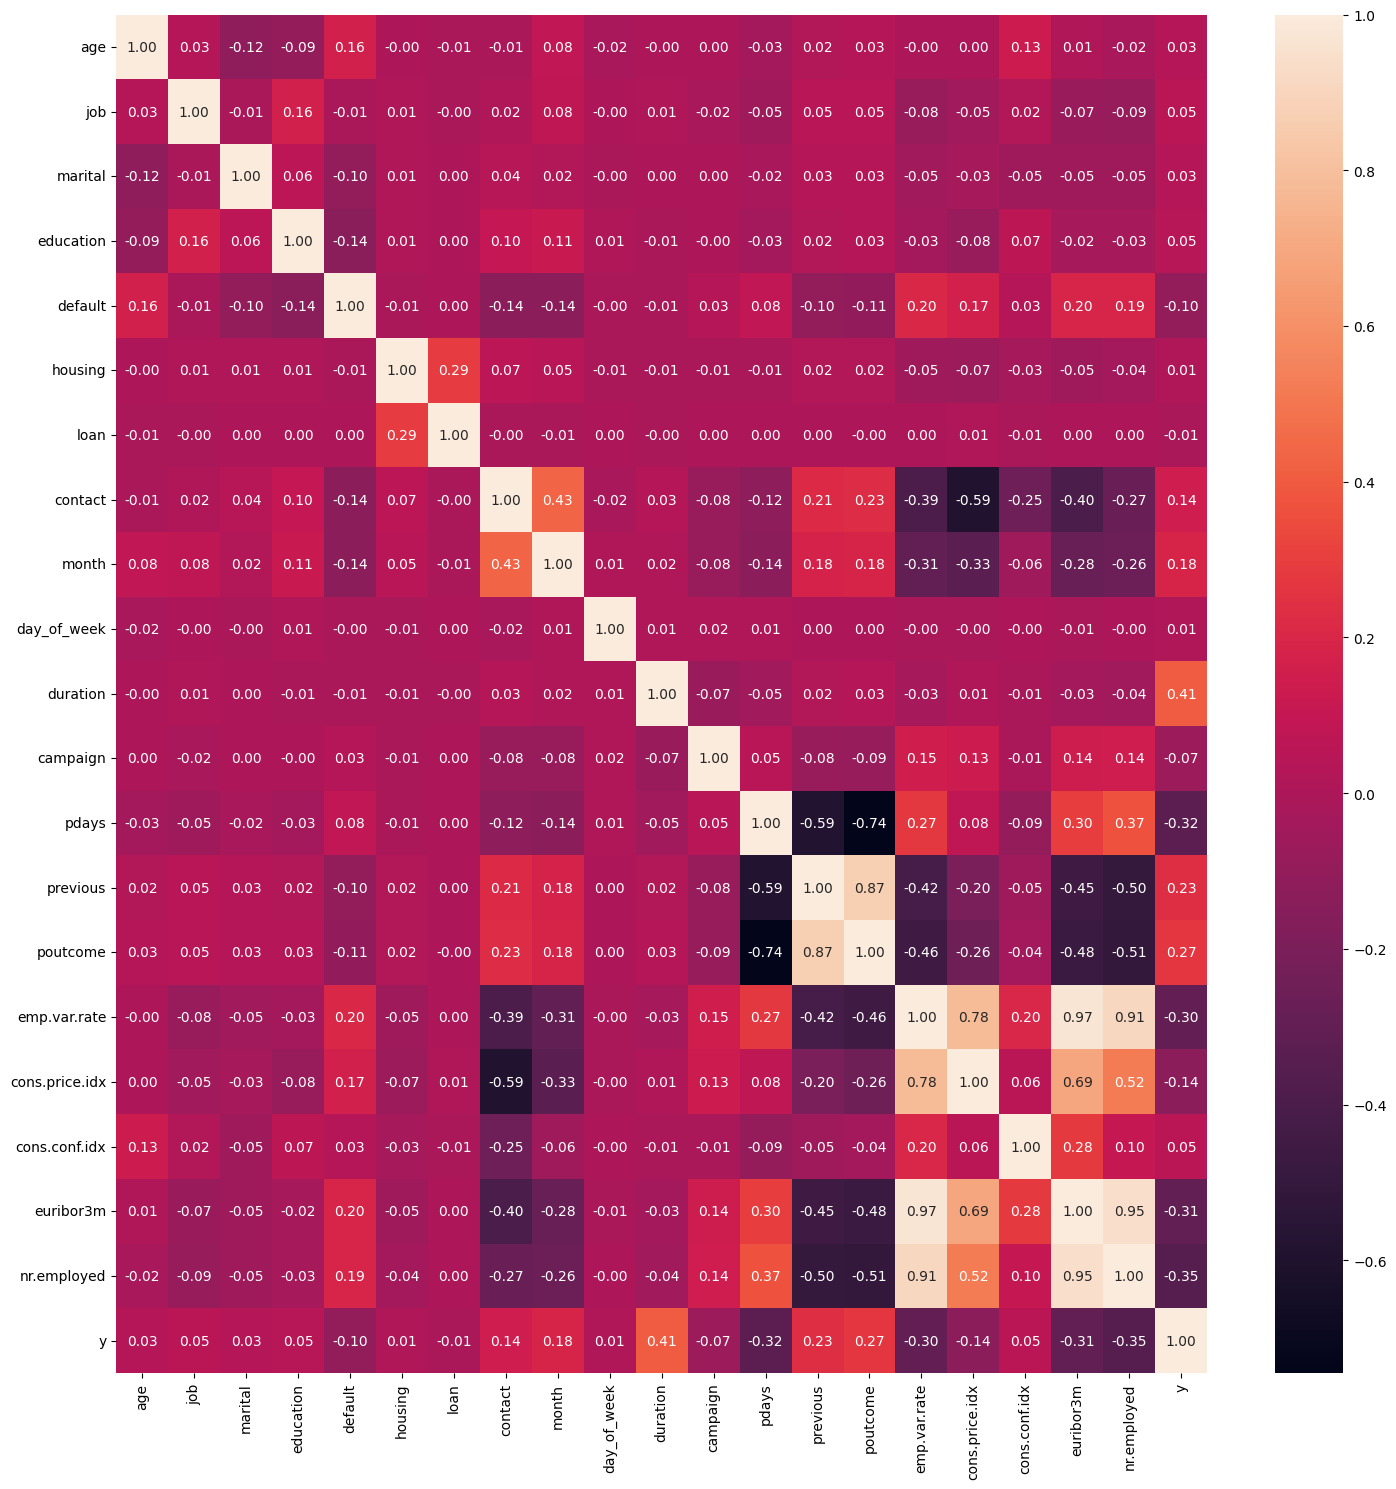

In [11]:
# Correlation heatmap - numerical/numerical relationships
fig, axes = plt.subplots(figsize=(15, 15))

sns.heatmap(total_data.corr(), annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

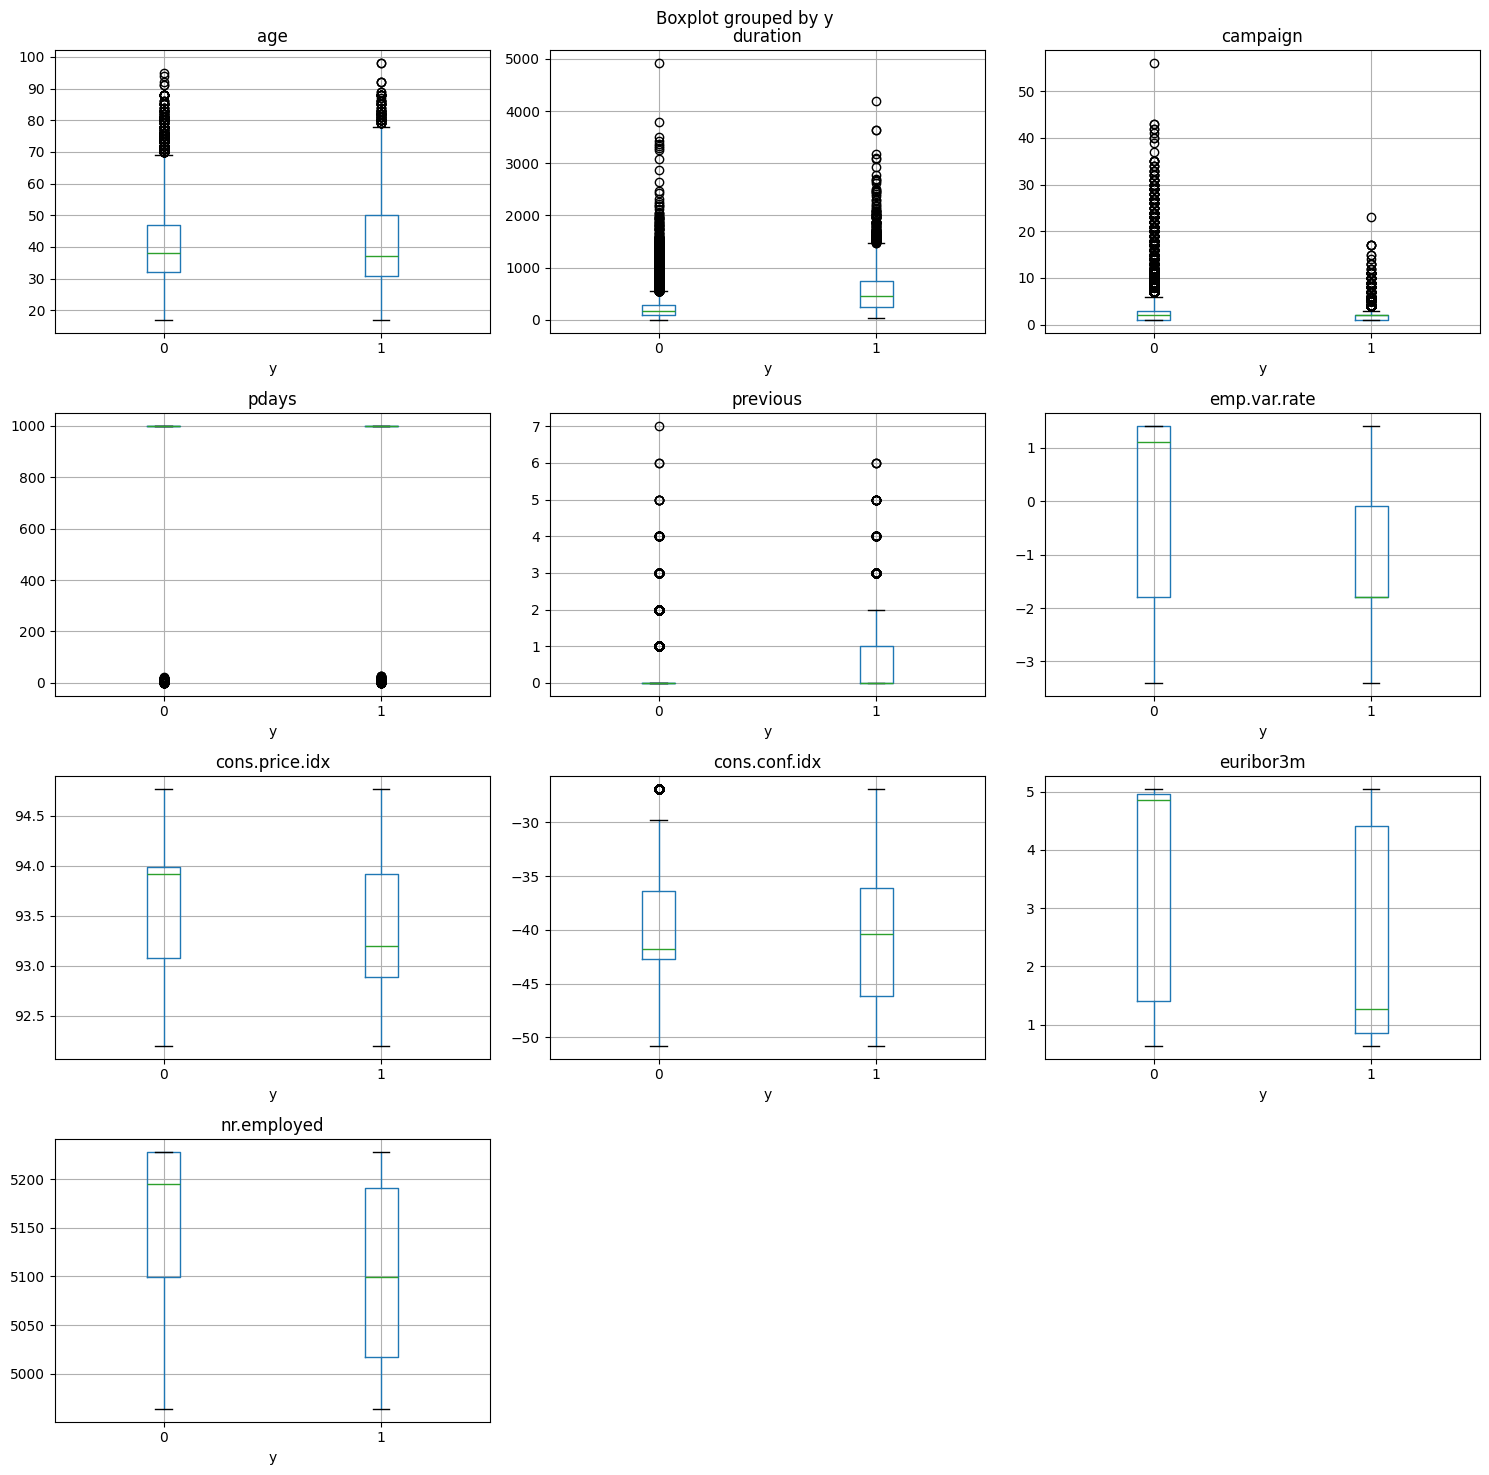

In [12]:
# Boxplots - numerical features vs target (categorical/numerical relationships)
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    total_data.boxplot(column=col, by="y", ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Step 7: Multivariate Analysis — Findings

Strongest correlations with y:
- duration — longest call duration strongly predicts subscription. Customers who stay on the phone longer are likely more interested. Note: **data leakage concern** — duration is only known after the call.
- poutcome — previous campaign success predicts future subscription
- previous — customers with prior campaign contact history more likely to subscribe
- nr.employed — when economy-wide employment is high, customers less likely to save in long-term deposits
- emp.var.rate — same reasoning as above
- pdays — correlation is partially artificial due to sentinel value 999

Multicollinearity concerns:
- pdays and previous — both measure prior campaign contact history
- emp.var.rate and nr.employed — both macroeconomic employment indicators
- cons.price.idx and emp.var.rate — both macroeconomic indicators moving together
- contact and cons.price.idx — notable correlation, less obviously explainable

Multicollinearity is a significant consideration — it violates one of the core assumptions of logistic regression and makes model coefficients less reliable.

Boxplot findings:
- duration shows the clearest difference between subscribers and non-subscribers
- Most other features show similar distributions between the two groups — model will need to combine multiple weak signals

Columns flagged for removal:
- default — near-zero variance
- pdays — sentinel value, will be replaced with engineered binary column

## Step 8: Feature Engineering

In [13]:
# Engineer binary column from pdays BEFORE dropping it
# 0 = never previously contacted (was 999), 1 = was previously contacted
total_data["was_previously_contacted"] = (total_data["pdays"] != 999).astype(int)

# Drop low-signal and problematic columns
total_data = total_data.drop(["default", "pdays"], axis=1)

print(f"Columns remaining: {list(total_data.columns)}")

Columns remaining: ['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'was_previously_contacted']


In [14]:
# Outlier handling - IQR method

# Duration
duration_stats = total_data["duration"].describe()
duration_iqr = duration_stats["75%"] - duration_stats["25%"]
upper_limit_duration = duration_stats["75%"] + 1.5 * duration_iqr
print(f"Duration upper limit: {upper_limit_duration}")
print(f"Duration max before: {duration_stats['max']}")

total_data = total_data[total_data["duration"] <= upper_limit_duration]

# Campaign
campaign_stats = total_data["campaign"].describe()
campaign_iqr = campaign_stats["75%"] - campaign_stats["25%"]
upper_limit_campaign = campaign_stats["75%"] + 1.5 * campaign_iqr
print(f"\nCampaign upper limit: {upper_limit_campaign}")
print(f"Campaign max before: {campaign_stats['max']}")

total_data = total_data[total_data["campaign"] <= upper_limit_campaign]

print(f"\nRows remaining after outlier removal: {total_data.shape[0]}")

Duration upper limit: 644.5
Duration max before: 4918.0

Campaign upper limit: 6.0
Campaign max before: 56.0

Rows remaining after outlier removal: 35951


In [15]:
# Feature scaling - MinMaxScaler on all columns except target y
from sklearn.preprocessing import MinMaxScaler

num_variables = ["age", "job", "marital", "education", "housing",
                 "loan", "contact", "month", "day_of_week", "duration",
                 "campaign", "was_previously_contacted", "previous",
                 "poutcome", "emp.var.rate", "cons.price.idx",
                 "cons.conf.idx", "euribor3m", "nr.employed"]

scaler = MinMaxScaler()
scal_features = scaler.fit_transform(total_data[num_variables])
total_data_scal = pd.DataFrame(scal_features, index=total_data.index, columns=num_variables)

# Add target column back - unscaled
total_data_scal["y"] = total_data["y"]

total_data_scal.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,was_previously_contacted,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,0.481481,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.405280,0.0,0.0,0.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0
1,0.493827,0.090909,0.0,0.142857,0.0,0.0,0.0,0.0,0.0,0.231366,0.0,0.0,0.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0
2,0.246914,0.090909,0.0,0.142857,0.5,0.0,0.0,0.0,0.0,0.350932,0.0,0.0,0.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0
3,0.283951,0.181818,0.0,0.285714,0.0,0.0,0.0,0.0,0.0,0.234472,0.0,0.0,0.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0
4,0.481481,0.090909,0.0,0.142857,0.0,0.5,0.0,0.0,0.0,0.476708,0.0,0.0,0.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0


## Step 9: Feature Selection

In [16]:
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split

# Define features and target
# Train/test split happens BEFORE SelectKBest to prevent data leakage
# (test data should never influence feature selection decisions)
X = total_data_scal.drop("y", axis=1)
y = total_data_scal["y"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Select the 7 best features based on chi-square test
selection_model = SelectKBest(chi2, k=7)
selection_model.fit(X_train, y_train)

# Get boolean mask of selected columns
ix = selection_model.get_support()

# Print selected features
print(f"Selected features: {X_train.columns.values[ix]}")

# Create new dataframes with only selected features
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns=X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns=X_test.columns.values[ix])

X_train_sel.head()

Selected features: <StringArray>
[                   'month', 'was_previously_contacted',
                 'previous',                 'poutcome',
             'emp.var.rate',                'euribor3m',
              'nr.employed']
Length: 7, dtype: str


,month,was_previously_contacted,previous,poutcome,emp.var.rate,euribor3m,nr.employed
0,0.333333,0.0,0.000000,0.0,1.000000,0.982090,1.000000
1,0.000000,1.0,0.142857,1.0,0.333333,0.153933,0.512287
2,0.555556,0.0,0.000000,0.0,0.687500,0.780322,0.877883
3,0.888889,0.0,0.000000,0.0,0.333333,0.165722,0.512287
4,0.000000,0.0,0.000000,0.0,0.937500,0.957379,0.859735


## Step 10: Save Results

In [17]:
import os

# Add target column back to both sets
X_train_sel["y"] = list(y_train)
X_test_sel["y"] = list(y_test)

# Save to CSV
base_dir = os.path.dirname(os.path.abspath("__file__"))
processed_dir = os.path.join(base_dir, "../data/processed")
os.makedirs(processed_dir, exist_ok=True)

X_train_sel.to_csv(os.path.join(processed_dir, "clean_train_data.csv"), index=False)
X_test_sel.to_csv(os.path.join(processed_dir, "clean_test_data.csv"), index=False)

print(f"Train set shape: {X_train_sel.shape}")
print(f"Test set shape: {X_test_sel.shape}")
print("Files saved successfully.")

X_train_sel.head()

Train set shape: (28760, 8)
Test set shape: (7191, 8)
Files saved successfully.


,month,was_previously_contacted,previous,poutcome,emp.var.rate,euribor3m,nr.employed,y
0,0.333333,0.0,0.000000,0.0,1.000000,0.982090,1.000000,0
1,0.000000,1.0,0.142857,1.0,0.333333,0.153933,0.512287,1
2,0.555556,0.0,0.000000,0.0,0.687500,0.780322,0.877883,0
3,0.888889,0.0,0.000000,0.0,0.333333,0.165722,0.512287,0
4,0.000000,0.0,0.000000,0.0,0.937500,0.957379,0.859735,0


## Logistic Regression Model

With the EDA complete and clean train/test data saved, we now train a Logistic Regression model to predict whether a customer will subscribe to a long-term deposit.

In [18]:
# Load the processed train and test data
base_dir = os.path.dirname(os.path.abspath("__file__"))
processed_dir = os.path.join(base_dir, "../data/processed")

train_data = pd.read_csv(os.path.join(processed_dir, "clean_train_data.csv"))
test_data = pd.read_csv(os.path.join(processed_dir, "clean_test_data.csv"))

# Quick look at both dataframes
train_data.head()

,month,was_previously_contacted,previous,poutcome,emp.var.rate,euribor3m,nr.employed,y
0,0.333333,0.0,0.000000,0.0,1.000000,0.982090,1.000000,0
1,0.000000,1.0,0.142857,1.0,0.333333,0.153933,0.512287,1
2,0.555556,0.0,0.000000,0.0,0.687500,0.780322,0.877883,0
3,0.888889,0.0,0.000000,0.0,0.333333,0.165722,0.512287,0
4,0.000000,0.0,0.000000,0.0,0.937500,0.957379,0.859735,0


In [19]:
test_data.head()

,month,was_previously_contacted,previous,poutcome,emp.var.rate,euribor3m,nr.employed,y
0,0.555556,0.0,0.0,0.0,0.687500,0.780322,0.877883,0
1,0.888889,0.0,0.0,0.0,0.333333,0.178871,0.512287,1
2,0.888889,0.0,0.0,0.0,0.333333,0.174790,0.512287,0
3,0.000000,0.0,0.0,0.0,0.333333,0.163228,0.512287,0
4,0.000000,0.0,0.0,0.0,0.333333,0.153933,0.512287,0


In [20]:
# Split train and test data into features (X) and target (y)
# X = feature columns (everything except the target)
# y = target column only
X_train = train_data.drop(["y"], axis=1)
y_train = train_data["y"]

X_test = test_data.drop(["y"], axis=1)
y_test = test_data["y"]

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize the model with default hyperparameters
model = LogisticRegression()

# .fit() starts the training run - the model establishes statistical relationships
# between the features and the target, learning weights for each feature
model.fit(X_train, y_train)

# Feed the test features into the trained model to generate predictions
prediction = model.predict(X_test)

# Compare predictions against the actual test target values
baseline_accuracy = accuracy_score(y_test, prediction)
print(f"Baseline accuracy (default hyperparameters): {baseline_accuracy}")

Baseline accuracy (default hyperparameters): 0.9207342511472674


## Model Optimization — Grid Search

The baseline accuracy gives us a starting point. Now we use GridSearchCV to systematically try every combination of hyperparameters and find the best configuration.

With 7 values of  x 4 values of  x 5 values of  = 140 combinations. With  that means **1,400 models** trained in total.

In [22]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter search space
# GridSearchCV will train a separate model for every possible combination
hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}

# Associate the grid with the model and hyperparameter search space
# cv=10 means 10-fold cross validation - each combination is trained and tested 10 times
# scoring="accuracy" means we pick the combination with the best accuracy
grid = GridSearchCV(model, hyperparams, scoring="accuracy", cv=10)
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [23]:
# Suppress ConvergenceWarnings that would flood the output
# (many of the 1400 models will hit max_iter before fully converging)
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

# Train all combinations using only X_train - test data is never touched here
# Internally uses cross-validation to evaluate each combination
grid.fit(X_train, y_train)

print(f"Best hyperparameters: {grid.best_params_}")

Best hyperparameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


In [24]:
# Retrain the model using the optimal hyperparameters found by grid search
model = LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [25]:
# Generate predictions with the optimized model and evaluate
prediction = model.predict(X_test)

optimized_accuracy = accuracy_score(y_test, prediction)
print(f"Baseline accuracy:  {baseline_accuracy}")
print(f"Optimized accuracy: {optimized_accuracy}")
print(f"Improvement:        {optimized_accuracy - baseline_accuracy:.6f}")

# The accuracy improvement from hyperparameter tuning is often small
# but the model is now more principled in its configuration

Baseline accuracy:  0.9207342511472674
Optimized accuracy: 0.9215686274509803
Improvement:        0.000834


## Save the Model

Unlike dataframes which are saved as CSV files, trained ML models are saved using  — which serializes the entire model object (weights, hyperparameters, everything) into a binary file that can be loaded and used later without retraining.

In [26]:
import os
from pickle import dump

# Create models directory if it does not exist
models_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "../models")
os.makedirs(models_dir, exist_ok=True)

# Save the trained model as a .sav file
# Filename encodes the key hyperparameters for easy identification later
# "wb" = write binary
model_path = os.path.join(models_dir, "logistic_regression_C-0.1_penalty-l2_solver-liblinear_42.sav")
dump(model, open(model_path, "wb"))

print(f"Model saved to: {model_path}")

Model saved to: c:\Users\Owner\Desktop\Coding Practice\Projects\4geeks_projects\ML_Logistic_Regression_Project-main\src\../models\logistic_regression_C-0.1_penalty-l2_solver-liblinear_42.sav
